# Checkerboard data analysis

Contact: laquitainesteeve@gmail.com based on Guilhelm's guilhelm-dev branch  

Description: This notebook is the second one of the Analysis Pipeline. If you haven't run the first one (Preprocessing) until the extraction of phy's data , you don't have the files needed to run this one. In this notebook, you will use phy sorted cluster spikes of a checkerboard recording to compute clusters raster plots, ganglion cells STA and fit ellipses on their receptive fields.

Execution time: <15 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**Requirements:**
- Run preprocessing before

**Required by**:
- 4-Chirp+Cell Typing.ipynb notebook

## Setup

1. Create, activate (env/..yml) and setup the virtual environment :

    ```python
    python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"
    ```

2. Configure your experiment in ./params.py

In [ ]:
!python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"

Installed kernelspec standard_analysis_pipeline in C:\Users\cboscarino\AppData\Roaming\jupyter\kernels\standard_analysis_pipeline


In [1]:
%reload_ext autoreload
%autoreload 2

# import packages
import os
import utils

# import custom packages
import params
import analyse_checkerboard_steeve as analysis

c:\Users\cboscarino\Documents\GitHub\Standard_analysis_pipeline\env\standard_analysis_pipeline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



-------- Creating all paths ---------

- "Sorting" path already exists
- "output" path already exists
- "triggers" path already exists


## Load data

- All the variables used in this part of the cell should always refer to your 'params.py' file, unless you want to manually change them only for this run (i.e. debugging). You may have to add those variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
- Mandatory for each run !
- Execution time: 9 secs

In [2]:
%%time 

# ask user to input the experiment parameters
# e.g., for the test dataset enter inputs: 0, 30, 42, 42
(
    recording_number,
    recording_name,
    stimulus_frequency,
    nb_checks_x,
    nb_checks_y,
    nb_pixels_per_check,
    check_directory,
) = analysis.get_all_inputs_for_checkerboard_analysis(params)

# load checkerboard experiment data
checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard = (
    analysis.load_checkerboard_data(
        params,
        check_directory,
        recording_name,
        nb_checks_x,
        nb_checks_y,
        stimulus_frequency,
    )
)

Which of the following is the checkerboard: 
	0 --> 00_AccCheck_30Hz_16px_42sq_50%30ND
	1 --> 01_Swn_30Hz_48pxCh_6pxL_50%30ND
	2 --> 02_Chirp_50Hz_50%30ND
	3 --> 03_DG_50Hz_50%30ND
	4 --> 04_PulsingGratings-PS0_40Hz_50%30ND
	5 --> 05_PulsingGratings-PS1_40Hz_50%30ND
	6 --> 06_PulsingGratings-PS2_40Hz_50%30ND
Selected recording: 00_AccCheck_30Hz_16px_42sq_50%30ND

Creating analysis directory...
./data/20251219_PulsingGratings_PupilSize\Analysis
./data/20251219_PulsingGratings_PupilSize\Analysis\triggers
Loading triggers from:	 data\20251219_PulsingGratings_PupilSize\Analysis\triggers\20251219_PulsingGratings_PupilSize_00_AccCheck_30Hz_16px_42sq_50%30ND_triggers.pkl
Total triggers number : 66728
Triggers type loaded : visual

Checkerboard Stats :
	- 37 min total duration
	- 66728 triggers
	- 55 complete sequences
	- 40 seconds per sequence

Reconstructing the stimulus...


100%|██████████| 33000/33000 [00:40<00:00, 806.82it/s]


Checkerboard stimulus created and saved at : data\20251219_PulsingGratings_PupilSize\Analysis\Checkerboard_Analysis_rec_0\checkerboard_42x42checks_33000frames.npy
Checkerboard stimulus shape: (33000, 42, 42)

Total : 344 neurons loaded
Cell ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172

## Extract responses to repeated sequence (raster plot and psth)

- Analysis on repeated sequence: all the variables used in this part of the cell should always refere to your 'params.py' file
unless you want to manually change them only for this run (i.e. debugging). 
You may have to add those variable into the function you want to adapt as only the minimal 
amount of var are currently given to functions as inputs.
- Requirements: cell 1 run
- Execution time: < 3 mins

Extracting responses to repeated sequence for each cell: 100%|██████████| 344/344 [00:01<00:00, 338.33it/s]
Plotting rasters for all cells: 100%|██████████| 361/361 [00:15<00:00, 23.91it/s]


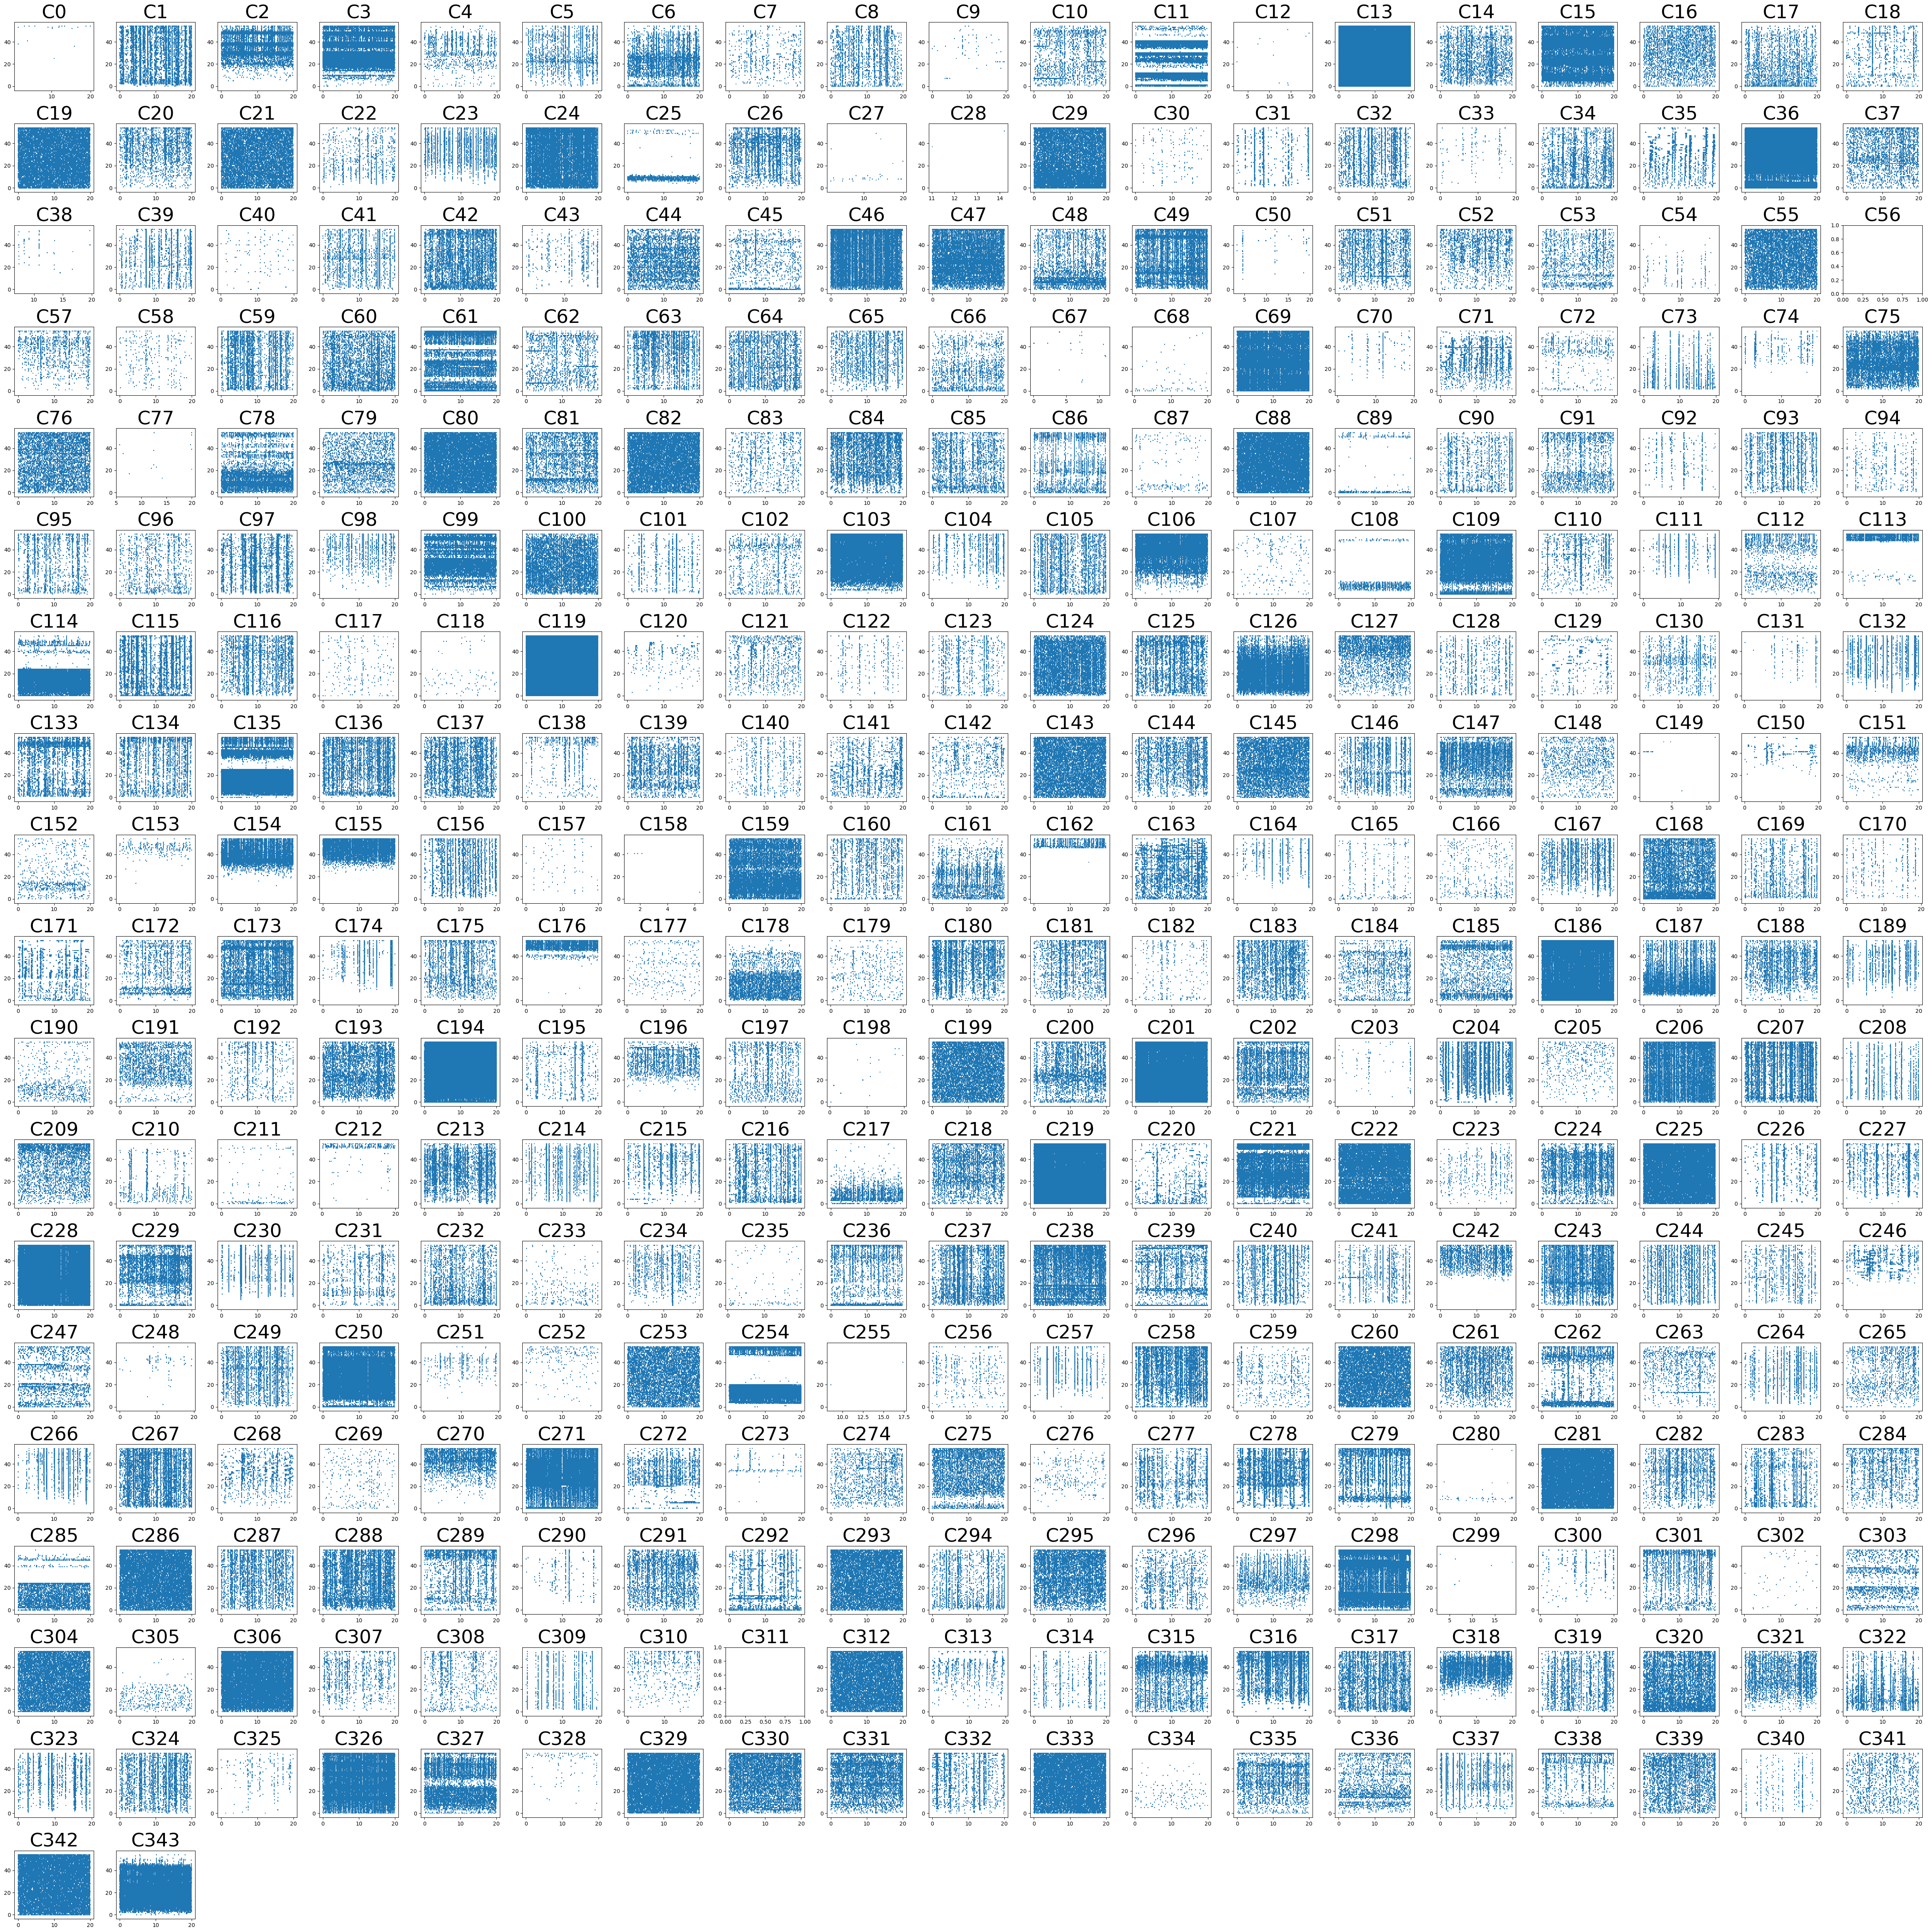

CPU times: total: 43.1 s
Wall time: 44.6 s


In [3]:
%%time

# inputs
save_data = True # save data or not
show_all_rasters = True # show all rasters in one figure in console to check extraction
save_single_cell_figures = False  # compute and save one figure per cell showing raster+psth or not (might take couple of seconds) you can skip this and plot raster directly after with STAs

# extract data
rep_seq_data = analysis.extract_all_cell_responses_to_repeated_sequences(
    checkerboard_spikes, 
    triggers, 
    nb_repeats, 
    stimulus_frequency, 
    cells_id,
    nb_frames_per_sequence=params.nb_frames_by_sequence,
    sequence_portion=(0.5, 1),
)
if save_data: 
    utils.save_obj(rep_seq_data, os.path.join(check_directory, "Check_rasters_data"))

# plot data
if show_all_rasters: 
    analysis.plot_all_rasters(rep_seq_data, cells_id)
if save_single_cell_figures:
    analysis.plot_and_save_single_cell_rasters(
        rep_seq_data, 
        cells_id, 
        check_directory, 
        title="Response to repeated sequence")

## Compute STAs

- **Requirements**: requires cell 1 run
- Execution time: < 5 min

In [4]:
%%time 

# Extract responses to non-repeated sequences, compute STA and save data
sta_data_file, sta_data = analysis.compute_spike_triggered_average(
    checkerboard_spikes,
    checkerboard,
    triggers,
    nb_repeats,
    stimulus_frequency,
    check_directory,
    temporal_dimension=params.sta_temporal_dimension,
    sequence_portion=(0, 0.5),
    nb_frames_per_sequence=params.nb_frames_by_sequence,
    sta_data_filename="sta_data_3D.pkl",
)

Computing STAs...


  8%|▊         | 28/344 [01:47<22:32,  4.28s/it]

Cell 28 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 16%|█▋        | 56/344 [03:44<22:33,  4.70s/it]

Cell 56 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


...

Cell 255 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 90%|█████████ | 311/344 [18:09<01:10,  2.14s/it]

Cell 311 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


100%|██████████| 344/344 [19:17<00:00,  3.36s/it]


CPU times: total: 18min 34s
Wall time: 19min 17s


Total : 344 cells found
Cell ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


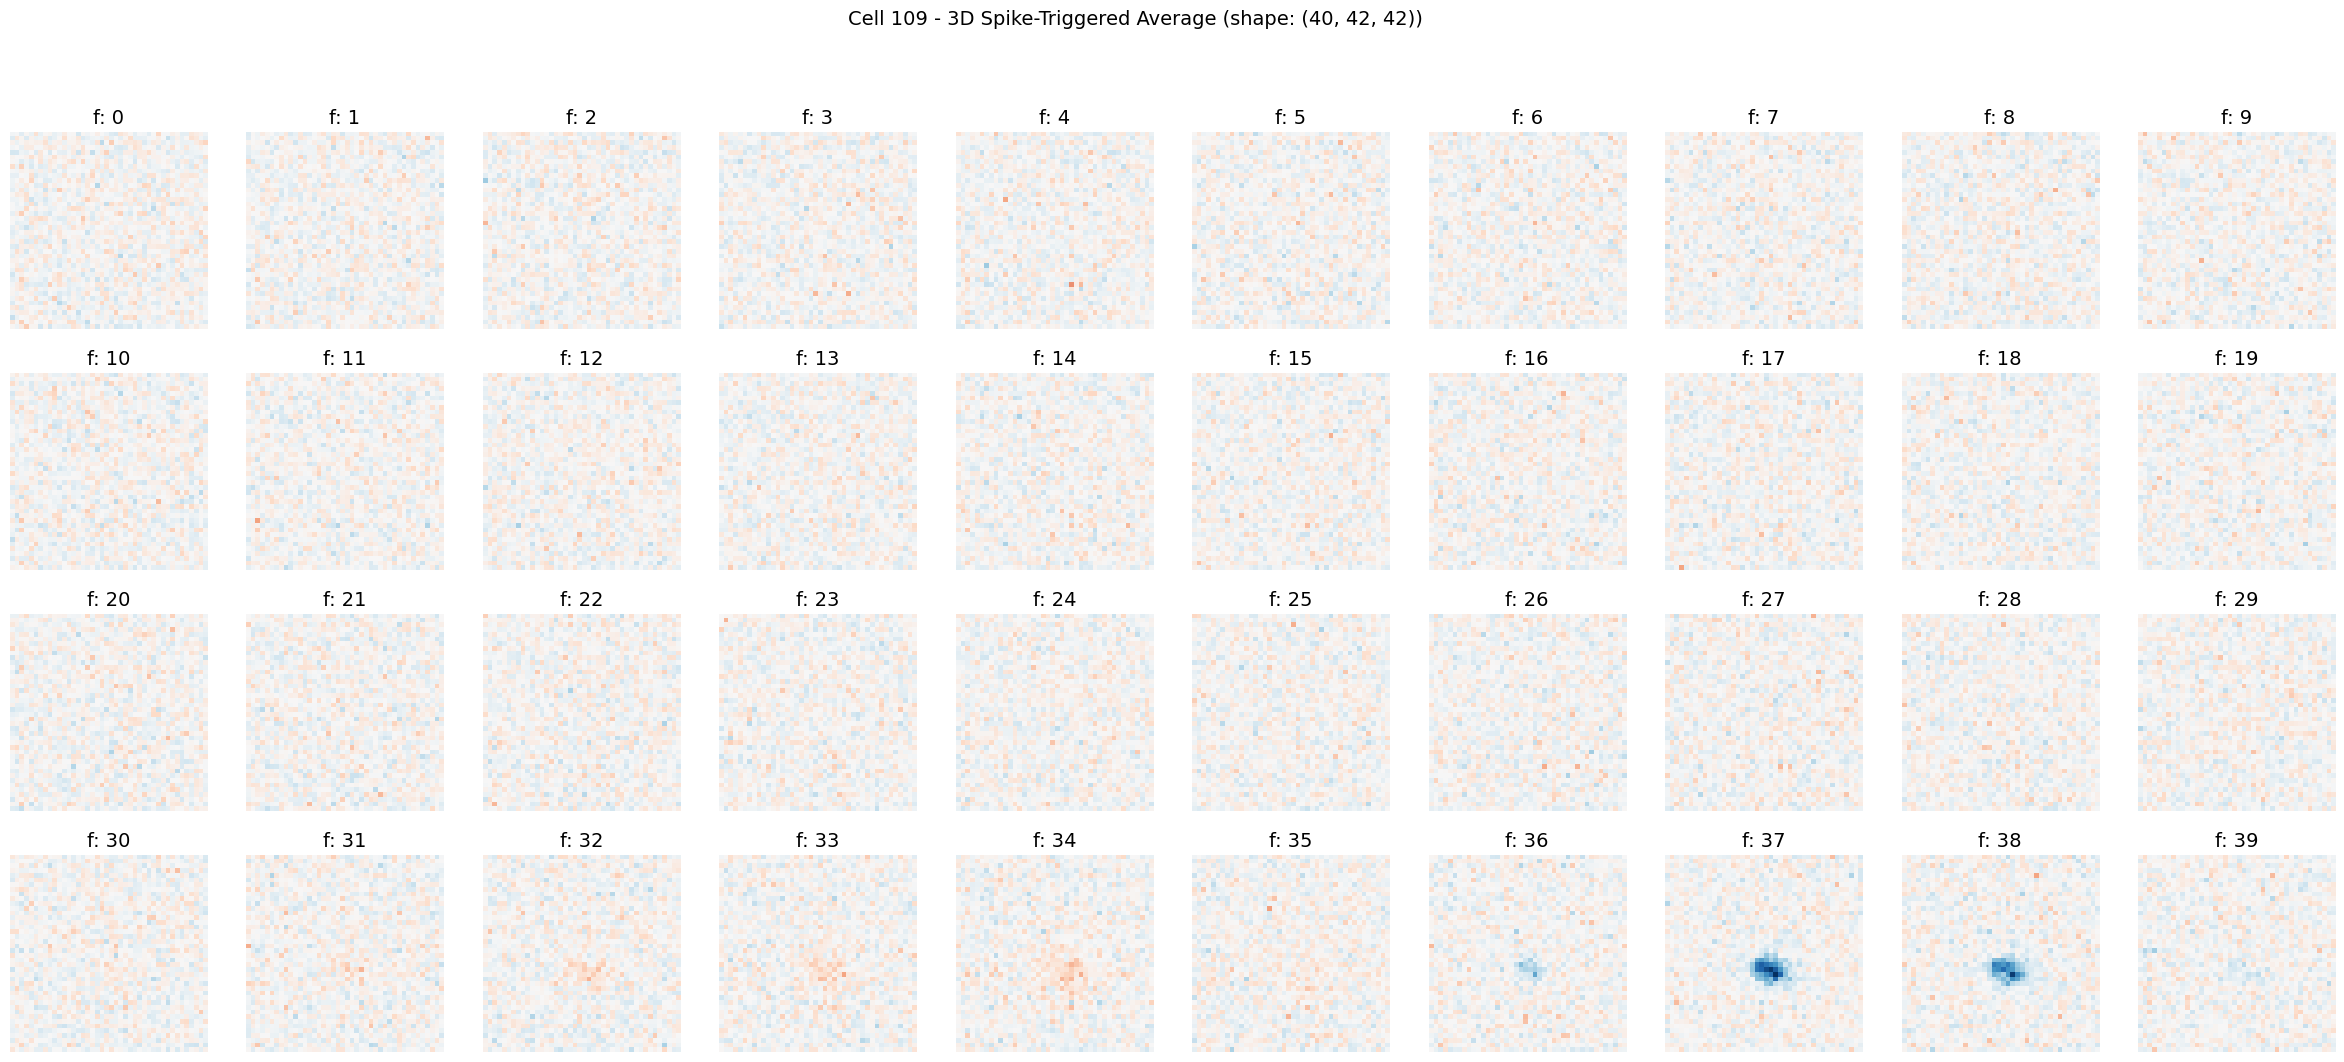

CPU times: total: 1.08 s
Wall time: 3.18 s


In [8]:
%%time 

# Check STA computation for one example cell
# ask the user to input a cell and plot its 3D sta (e.g., 1)
analysis.plot_one_cell_3D_spike_triggered_average(
    sta_data, 
    max_frames_to_show=params.sta_temporal_dimension,
    n_frames_per_line=10,
    fontsize=14)

## Analyse STAs to identify receptive fields

- **Requirements**: requires cell 1 run and cell 4 output
- Execution time: 10 secs

Plotting STAs for all cells: 100%|██████████| 361/361 [00:00<00:00, 1664.51it/s]



Spatial STAs for 344 cells
340 fitted ellipse (of which: 303 good (green), 37 not good (orange))
4 failed ellipse fitting (red)



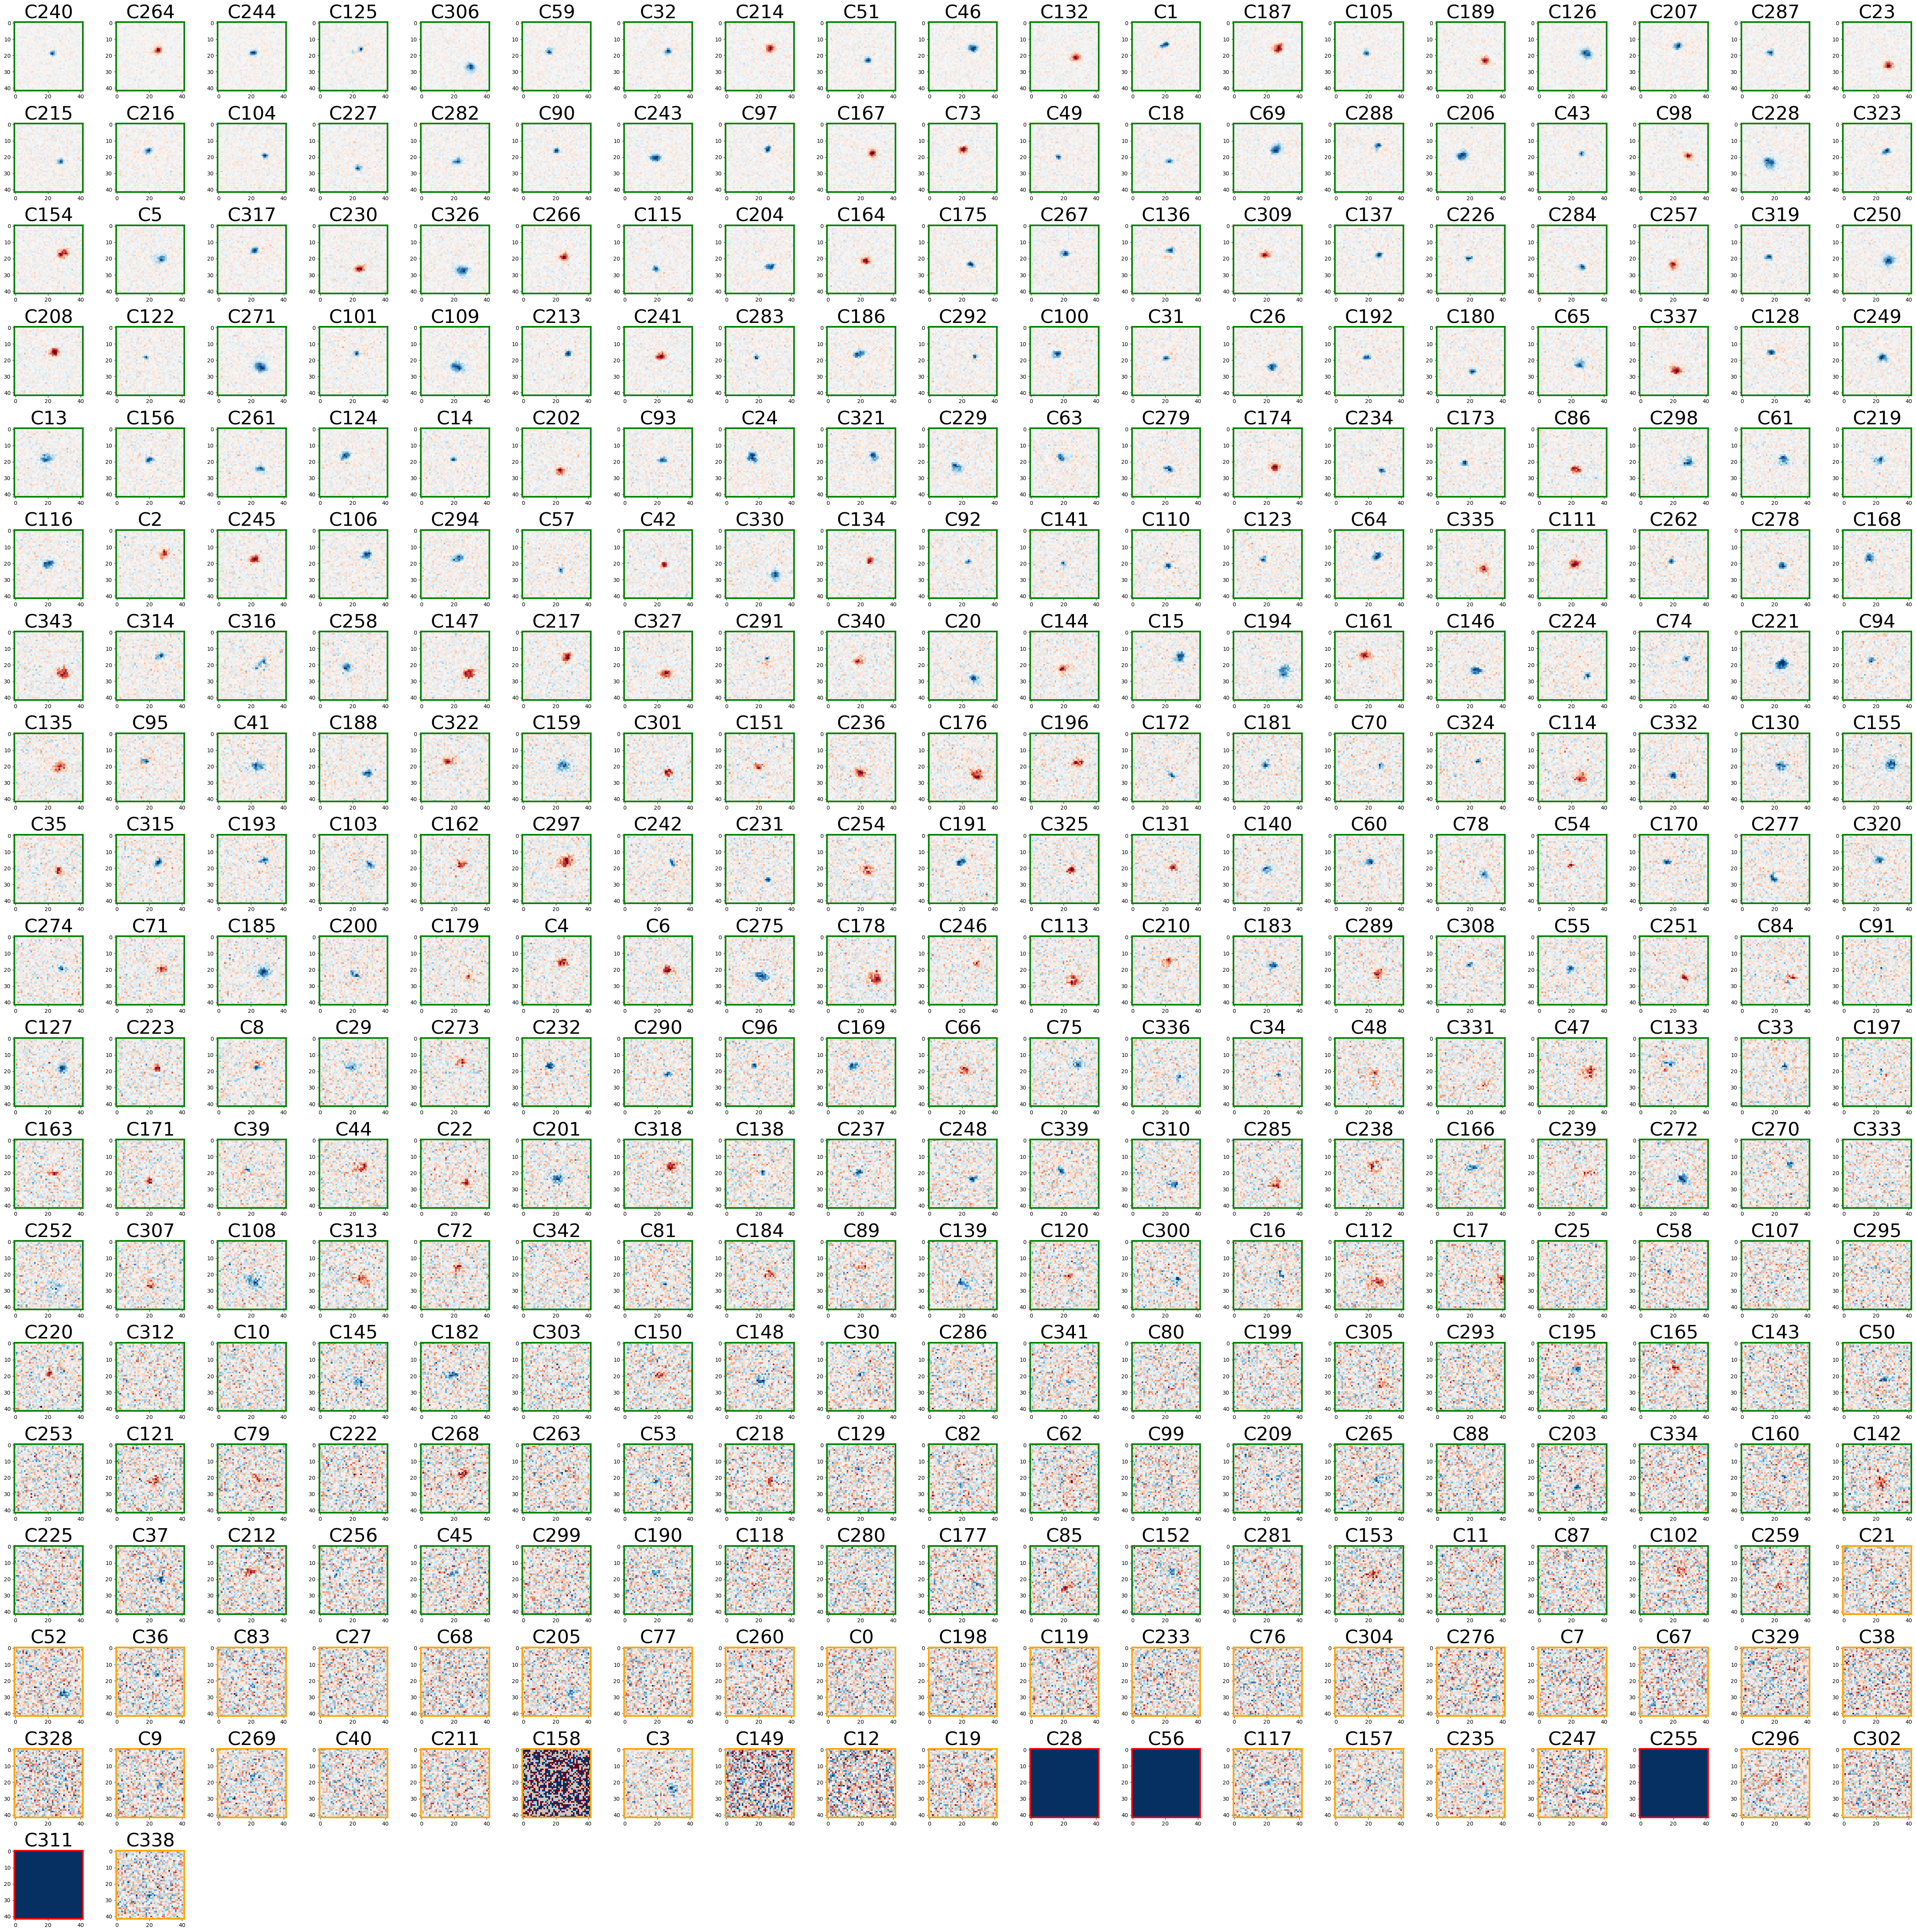

CPU times: total: 51.1 s
Wall time: 45.1 s


In [9]:
%%time 

show_all_stas = True
get_extended_analysis = True

# Analyze STAs to extract receptive field properties for all cells, 
# add it to the sta_data dictionary and save it
sta_data_analysed = analysis.analyse_all_stas(
    sta_data, 
    directory=check_directory,
    data_filename="sta_data_analysed.pkl",
    method="matias"
)

# Extend analysis to physical units
# adding to the analysis dictionary the RF properties in physical units (um, s, etc.) and not only in pixels and time bins as before,
# and stores the results
if get_extended_analysis:
    sta_data_analysed = analysis.extend_sta_analysis_to_physical_units(
        sta_data_analysed,
        pixels_per_check=nb_pixels_per_check,
        pxl_size_dmd_um=params.pxl_size_dmd,
        sta_frequency=stimulus_frequency,
        directory=check_directory,
        data_filename="sta_data_analysed_extended.pkl",
    )

if show_all_stas:
    analysis.plot_all_stas(sta_data_analysed, level_factor=0.4, order_by_property="rf_snr", border_width=3)

## Visualize receptive fields 

- Check the figure saved in the Analysis/ folder.
- Execution time: 30 secs

In [15]:
%%time

# Re-loading analysed STA data if already computed and saved, 
# to run following analysis without re-computing it
# - False if you run the previous cell to compute the analysed STA data, so it is already in memory
# - True if you just want to run following analysis and the analysed STA data has already been computed and saved
load_sta_data = True
if load_sta_data:
    sta_data_analysed_file = os.path.join(check_directory, "sta_data_analysed.pkl")
    sta_data_extended_file = os.path.join(check_directory, "sta_data_analysed_extended.pkl")
    if os.path.exists(sta_data_extended_file):
        sta_data_analysed = utils.load_obj(sta_data_extended_file)
        print(f"Loaded extended analysed STA data from {sta_data_extended_file}")
    elif os.path.exists(sta_data_analysed_file):
        sta_data_analysed = utils.load_obj(sta_data_analysed_file)
        print(f"Loaded analysed STA data from {sta_data_analysed_file}")
    else:
        print("Analysed STA data file not found. Check the filename or run the previous cell to compute and save the analysed STA data before running this cell.")
    rep_seq_data_file = os.path.join(check_directory, "Check_rasters_data.pkl")
    if os.path.exists(rep_seq_data_file):
        rep_seq_data = utils.load_obj(rep_seq_data_file)
    else:
        print(f"Repeated sequence data file not found at {rep_seq_data_file}. Check the filename or run the previous cell to compute and save the repeated sequence data before running this cell.")    

# Plotting STAs & their fitted ellipses for all cells 
analysis.plot_sta_fitted_with_ellipse(
    sta_data_analysed, 
    check_directory,
    add_raster_plot=True,
    rep_seq_data=rep_seq_data,
    cell_ids=None, # list of cell ids to plot, e.g., [208, 209, 210], if None it will plot all cells
    show_figures=False,
    xdim=7,
    ydim=5,
)

Loaded extended analysed STA data from data\20251219_PulsingGratings_PupilSize\Analysis\Checkerboard_Analysis_rec_0\sta_data_analysed_extended.pkl


Generating STA and ellipse fitting figures for each cell: 100%|██████████| 344/344 [05:03<00:00,  1.13it/s]

CPU times: total: 4min 50s
Wall time: 5min 3s
